# Day2++ — Manifold Coverage Analysis

This notebook tests whether transfer robustness is governed by **source-manifold coverage** rather than simple source-target similarity. It extends Day2+ geometry analysis by calculating source volume, target containment, Mahalanobis distance, and nearest-neighbor support metrics.

In [1]:
from pathlib import Path
import sys, itertools, warnings

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == "notebooks" else Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "figures" / "day2plus"
RESULT_DIR = PROJECT_ROOT / "results" / "day2plus"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("FIG_DIR:", FIG_DIR)
print("RESULT_DIR:", RESULT_DIR)
assert SRC_DIR.exists(), f"Missing src directory: {SRC_DIR}"
assert DATA_DIR.exists(), f"Missing raw data directory: {DATA_DIR}"

PROJECT_ROOT: C:\Users\hg\PycharmProjects\mox_calibration_transfer
DATA_DIR: C:\Users\hg\PycharmProjects\mox_calibration_transfer\data\raw
FIG_DIR: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2plus
RESULT_DIR: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2plus


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf
from sklearn.neighbors import NearestNeighbors
from scipy.stats import pearsonr, spearmanr
from day2plus_transfer_matrix import TARGET_GAS, assert_no_label_leakage, build_feature_table, get_feature_columns, evaluate_split
warnings.filterwarnings("ignore")
BOARDS = ["B1", "B2", "B3", "B4", "B5"]
PRIMARY_FEATURE_SET = "physics"
PRIMARY_MODEL = "RandomForest"
RANDOM_STATE = 42

## 1. Load methane feature table

In [3]:
df = build_feature_table(DATA_DIR, gas=TARGET_GAS)
feature_cols = get_feature_columns(df, PRIMARY_FEATURE_SET)
leakage_report = assert_no_label_leakage(df)
print("Leakage check:", leakage_report[PRIMARY_FEATURE_SET])
print("Feature table:", df.shape)
print("Boards:", sorted(df["board"].unique()))
print("Physics features:", len(feature_cols))
df.head()

Leakage check: {'n_features': 71, 'leakage_overlap': [], 'ok': True}
Feature table: (160, 126)
Boards: ['B1', 'B2', 'B3', 'B4', 'B5']
Physics features: 71


,filename,sample_id,board,gas,concentration_code,concentration_numeric,replicate,raw_s1_mean,raw_s1_std,raw_s1_min,...,phys_s8_late_slope,phys_s8_recovery_residual,phys_s8_recovery_norm,phys_response_l2,phys_response_mean,phys_response_std,phys_baseline_mean,phys_baseline_std,phys_recovery_l2,phys_recovery_mean_abs
0,B1_GMe_F010_R1.txt,B1_GMe_F010_R1,B1,GMe,F010,10,R1,37.220347,3.266759,28.97,...,-6.662357e-07,-0.01,-0.035714,42.384114,-10.90875,10.273792,33.15375,22.499227,0.631348,0.15750
1,B1_GMe_F010_R2.txt,B1_GMe_F010_R2,B1,GMe,F010,10,R2,33.910132,2.747687,26.76,...,-1.801653e-06,0.04,0.100000,37.151599,-9.50625,9.064291,30.22875,20.355245,0.226936,0.05625
2,B1_GMe_F010_R3.txt,B1_GMe_F010_R3,B1,GMe,F010,10,R3,39.762511,4.019628,30.08,...,2.227258e-06,0.08,0.210526,48.555521,-12.59000,11.670335,35.79625,23.477773,0.135647,0.03000
3,B1_GMe_F010_R4.txt,B1_GMe_F010_R4,B1,GMe,F010,10,R4,38.070450,3.972367,27.92,...,-4.038182e-06,0.00,0.000000,49.641586,-12.84625,11.958668,34.77625,22.612572,0.390000,0.07375
4,B1_GMe_F020_R1.txt,B1_GMe_F020_R1,B1,GMe,F020,20,R1,36.109566,4.944539,25.06,...,3.167588e-06,0.08,0.135593,54.306106,-14.25500,12.862314,33.05500,22.365820,0.831745,0.23000


## 2. Build/load transfer-performance table

This computes all source-board combinations from size 1 to 4, with target board excluded from the source set. If cached results exist, they are reused.

In [4]:
perf_csv = RESULT_DIR / "coverage_transfer_performance.csv"
if perf_csv.exists():
    transfer_df = pd.read_csv(perf_csv)
    print("Loaded:", perf_csv)
else:
    rows, pred_rows = [], []
    for k in range(1, len(BOARDS)):
        for sources in itertools.combinations(BOARDS, k):
            sources = list(sources)
            for target in BOARDS:
                if target in sources:
                    continue
                metrics, preds = evaluate_split(df, sources, target, PRIMARY_FEATURE_SET, PRIMARY_MODEL, RANDOM_STATE)
                metrics.update({"source_boards":"+".join(sources), "target_board":target, "n_source_boards":len(sources), "b5_source":"B5" in sources})
                rows.append(metrics)
                preds["source_boards"] = "+".join(sources)
                preds["target_board"] = target
                pred_rows.append(preds)
    transfer_df = pd.DataFrame(rows)
    transfer_df.to_csv(perf_csv, index=False)
    pd.concat(pred_rows, ignore_index=True).to_csv(RESULT_DIR / "coverage_transfer_predictions.csv", index=False)
    print("Saved:", perf_csv)
transfer_df.head()

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2plus\coverage_transfer_performance.csv


,source_boards,n_source_boards,target_board,feature_set,model,n_train,n_test,rmse,mae,r2,includes_B5_source,b5_source
0,B1,1,B2,physics,RandomForest,40,40,6.237779,4.825625,0.952836,False,False
1,B1,1,B3,physics,RandomForest,40,40,10.385157,9.590625,0.869271,False,False
2,B1,1,B4,physics,RandomForest,40,20,9.155391,8.202500,0.898399,False,False
3,B1,1,B5,physics,RandomForest,40,20,7.793647,7.287500,0.926375,False,False
4,B2,1,B1,physics,RandomForest,40,40,8.160622,6.738750,0.919278,False,False


## 3. Compute manifold coverage metrics

Metrics are computed in globally standardized physics-feature space as an unsupervised diagnostic. Target labels are never used.

Key metrics: `source_log_volume`, `source_trace`, `source_effective_rank`, `target_containment_frac`, `target_mean_mahalanobis`, and `target_mean_nn_dist`.

In [5]:
def stable_cov(X):
    lw = LedoitWolf().fit(X)
    cov = lw.covariance_
    eig = np.clip(np.linalg.eigvalsh(cov), 1e-12, None)
    return cov, eig

def effective_rank(eig):
    p = eig / eig.sum()
    return float(np.exp(-(p * np.log(p + 1e-12)).sum()))

def coverage_metrics(df, feature_cols, sources, target, n_pca=8):
    src = df["board"].isin(sources)
    tgt = df["board"].eq(target)
    X_all = df[feature_cols].astype(float).values
    Xs_raw = df.loc[src, feature_cols].astype(float).values
    Xt_raw = df.loc[tgt, feature_cols].astype(float).values
    scaler = StandardScaler().fit(X_all)
    Xs, Xt = scaler.transform(Xs_raw), scaler.transform(Xt_raw)
    n_comp = min(n_pca, Xs.shape[0]-1, Xt.shape[0]-1, Xs.shape[1])
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE).fit(np.vstack([Xs, Xt]))
    Zs, Zt = pca.transform(Xs), pca.transform(Xt)
    mu = Zs.mean(axis=0)
    cov, eig = stable_cov(Zs)
    inv = np.linalg.pinv(cov)
    src_md2 = np.sum((Zs-mu) @ inv * (Zs-mu), axis=1)
    tgt_md2 = np.sum((Zt-mu) @ inv * (Zt-mu), axis=1)
    radius95 = float(np.quantile(src_md2, 0.95))
    nn = NearestNeighbors(n_neighbors=1).fit(Zs)
    nn_d, _ = nn.kneighbors(Zt)
    return {
        "source_log_volume": float(np.sum(np.log(eig))),
        "source_trace": float(eig.sum()),
        "source_effective_rank": effective_rank(eig),
        "source_radius95": radius95,
        "target_containment_frac": float(np.mean(tgt_md2 <= radius95)),
        "target_mean_mahalanobis": float(np.mean(np.sqrt(np.maximum(tgt_md2, 0)))),
        "target_p95_mahalanobis": float(np.quantile(np.sqrt(np.maximum(tgt_md2, 0)), 0.95)),
        "target_mean_nn_dist": float(nn_d.mean()),
        "target_p95_nn_dist": float(np.quantile(nn_d, 0.95)),
        "centroid_dist_pca": float(np.linalg.norm(Zs.mean(axis=0)-Zt.mean(axis=0))),
        "pca_explained_variance_sum": float(pca.explained_variance_ratio_.sum()),
        "n_pca_components": int(n_comp),
    }

rows = []
for _, r in transfer_df.iterrows():
    sources = r["source_boards"].split("+")
    m = coverage_metrics(df, feature_cols, sources, r["target_board"], n_pca=8)
    d = r.to_dict(); d.update(m); rows.append(d)
coverage_df = pd.DataFrame(rows)
out_csv = RESULT_DIR / "manifold_coverage_metrics.csv"
coverage_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)
coverage_df.head()

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2plus\manifold_coverage_metrics.csv


,source_boards,n_source_boards,target_board,feature_set,model,n_train,n_test,rmse,mae,r2,...,source_effective_rank,source_radius95,target_containment_frac,target_mean_mahalanobis,target_p95_mahalanobis,target_mean_nn_dist,target_p95_nn_dist,centroid_dist_pca,pca_explained_variance_sum,n_pca_components
0,B1,1,B2,physics,RandomForest,40,40,6.237779,4.825625,0.952836,...,3.276152,9.183408,0.0,7.048163,8.780448,5.383485,7.538855,5.479912,0.983157,8
1,B1,1,B3,physics,RandomForest,40,40,10.385157,9.590625,0.869271,...,3.254658,9.617461,0.0,9.528867,12.116801,6.699101,9.419822,6.451103,0.982092,8
2,B1,1,B4,physics,RandomForest,40,20,9.155391,8.202500,0.898399,...,3.274340,9.570911,0.0,8.351042,9.603240,6.081049,6.996866,6.686483,0.984111,8
3,B1,1,B5,physics,RandomForest,40,20,7.793647,7.287500,0.926375,...,2.999854,8.087251,0.0,16.049505,40.728596,11.884896,27.566145,8.945752,0.981435,8
4,B2,1,B1,physics,RandomForest,40,40,8.160622,6.738750,0.919278,...,3.542014,11.485776,0.0,6.683068,9.148053,5.084346,7.690326,5.479912,0.983157,8


## 4. Correlation summary

In [6]:
def corr_table(data, y="rmse"):
    cols = ["source_log_volume", "source_trace", "source_effective_rank", "source_radius95",
            "target_containment_frac", "target_mean_mahalanobis", "target_p95_mahalanobis",
            "target_mean_nn_dist", "target_p95_nn_dist", "centroid_dist_pca"]
    rows = []
    for col in cols:
        tmp = data[[y, col]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(tmp) >= 3 and tmp[col].nunique() > 1:
            pr, pp = pearsonr(tmp[col], tmp[y])
            sr, sp = spearmanr(tmp[col], tmp[y])
            rows.append({"metric":col, "pearson_r":pr, "pearson_p":pp, "spearman_rho":sr, "spearman_p":sp})
    return pd.DataFrame(rows).sort_values("spearman_rho")

corr_all = corr_table(coverage_df)
corr_all.to_csv(RESULT_DIR / "manifold_coverage_correlations.csv", index=False)
corr_all

,metric,pearson_r,pearson_p,spearman_rho,spearman_p
7,target_mean_nn_dist,-0.190889,0.100901,-0.166486,0.153412
5,target_mean_mahalanobis,-0.166437,0.153537,-0.086970,0.458123
1,source_trace,0.032223,0.783747,-0.086373,0.461229
6,target_p95_mahalanobis,-0.329259,0.003921,-0.065349,0.577510
4,target_containment_frac,0.010725,0.927234,-0.055465,0.636472
8,target_p95_nn_dist,-0.331340,0.003687,-0.011494,0.922036
2,source_effective_rank,-0.012054,0.918250,-0.007809,0.946987
0,source_log_volume,-0.001586,0.989226,-0.000768,0.994781
3,source_radius95,0.045378,0.699065,0.004296,0.970821
9,centroid_dist_pca,0.143023,0.220909,0.018308,0.876113


## 5. Plot helpers

In [7]:
def annotate_corr(ax, x, y):
    tmp = pd.DataFrame({"x":x, "y":y}).replace([np.inf, -np.inf], np.nan).dropna()
    pr, _ = pearsonr(tmp["x"], tmp["y"])
    sr, _ = spearmanr(tmp["x"], tmp["y"])
    ax.text(0.02, 0.98, f"Pearson r={pr:.2f}\nSpearman ρ={sr:.2f}", transform=ax.transAxes,
            va="top", ha="left", bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

def scatter_metric(data, x_col, title, filename, label_top=6):
    fig, ax = plt.subplots(figsize=(9,6), dpi=160)
    sc = ax.scatter(data[x_col], data["rmse"], c=data["n_source_boards"],
                    s=np.where(data["b5_source"], 95, 60), alpha=0.82)
    tmp = data[[x_col, "rmse"]].dropna()
    m, b = np.polyfit(tmp[x_col], tmp["rmse"], 1)
    xs = np.linspace(tmp[x_col].min(), tmp[x_col].max(), 100)
    ax.plot(xs, m*xs+b, linestyle="--", linewidth=1.5)
    annotate_corr(ax, data[x_col], data["rmse"])
    for _, r in data.nlargest(label_top, "rmse").iterrows():
        ax.annotate(f'{r["source_boards"]}→{r["target_board"]}', (r[x_col], r["rmse"]), fontsize=8, xytext=(4,4), textcoords="offset points")
    ax.set_xlabel(x_col); ax.set_ylabel("RMSE"); ax.set_title(title)
    cb = fig.colorbar(sc, ax=ax); cb.set_label("Number of source boards")
    fig.tight_layout(); fig.savefig(FIG_DIR / filename, bbox_inches="tight"); plt.show()

## 6. Source volume vs transfer RMSE

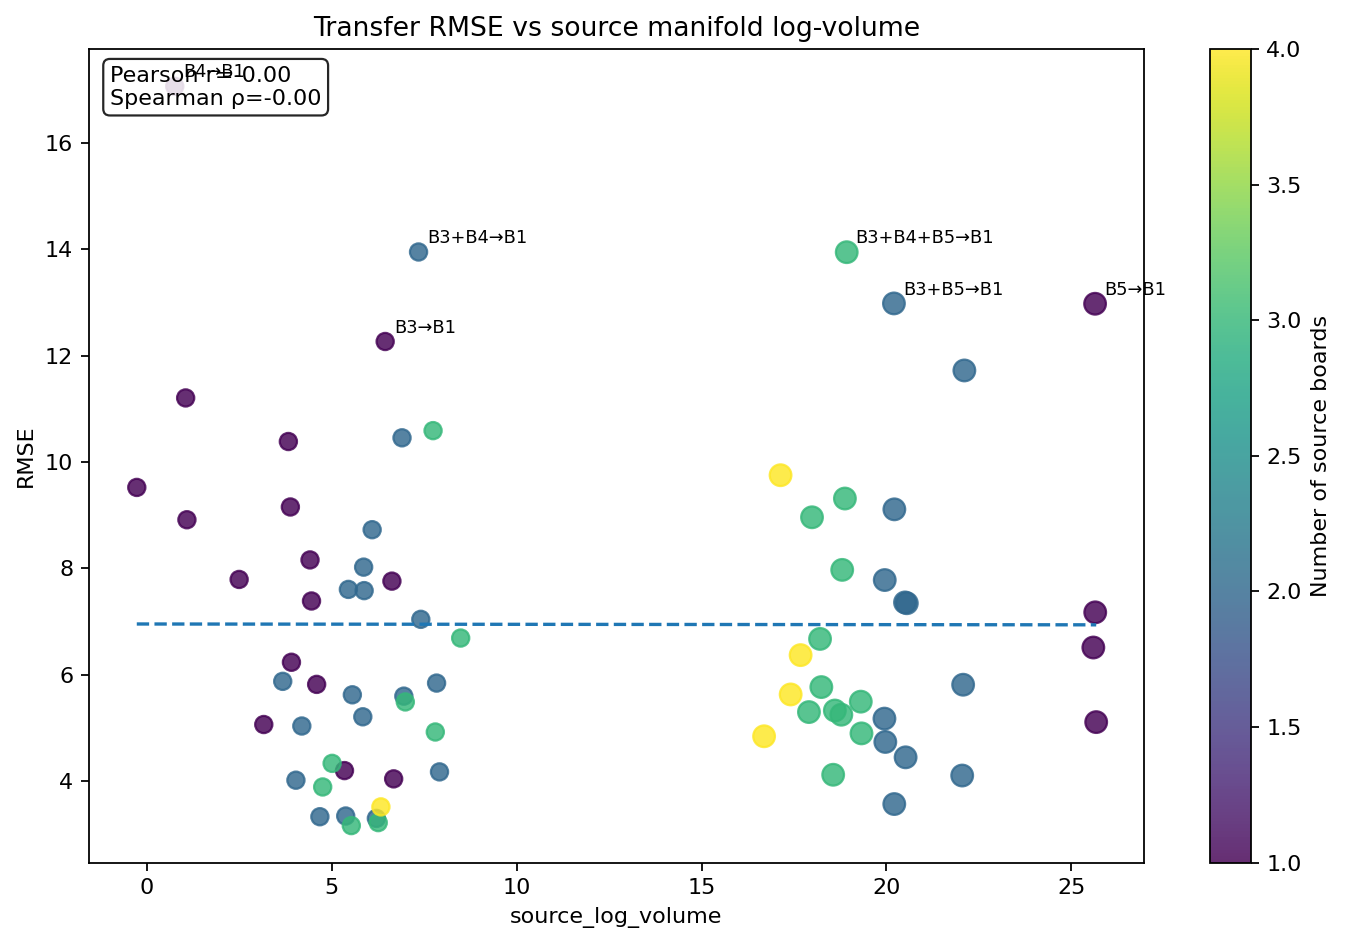

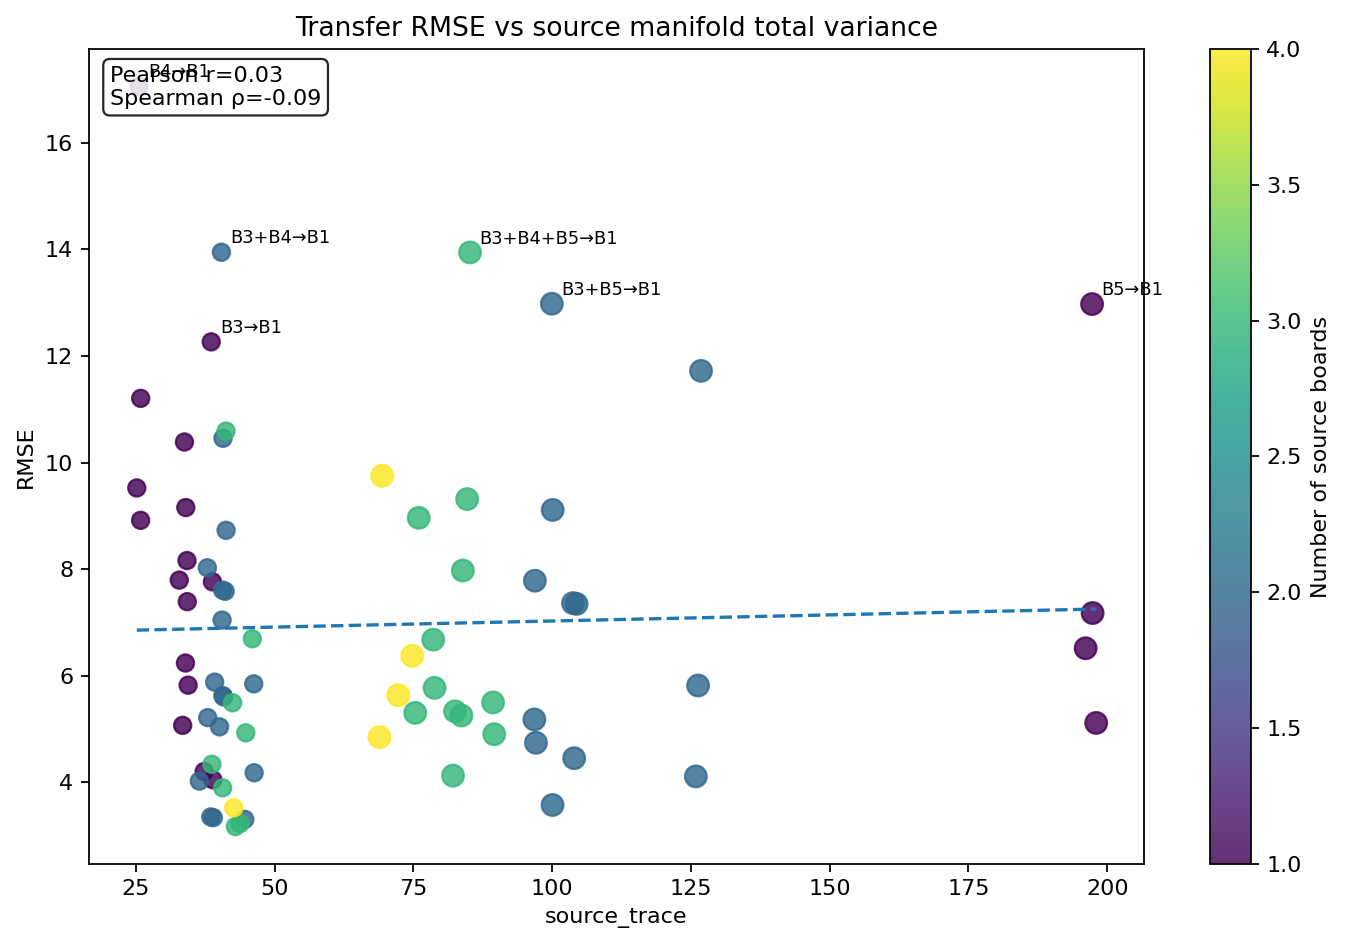

In [8]:
scatter_metric(coverage_df, "source_log_volume", "Transfer RMSE vs source manifold log-volume", "coverage_rmse_vs_source_log_volume.png")
scatter_metric(coverage_df, "source_trace", "Transfer RMSE vs source manifold total variance", "coverage_rmse_vs_source_trace.png")

## 7. Target containment vs transfer RMSE

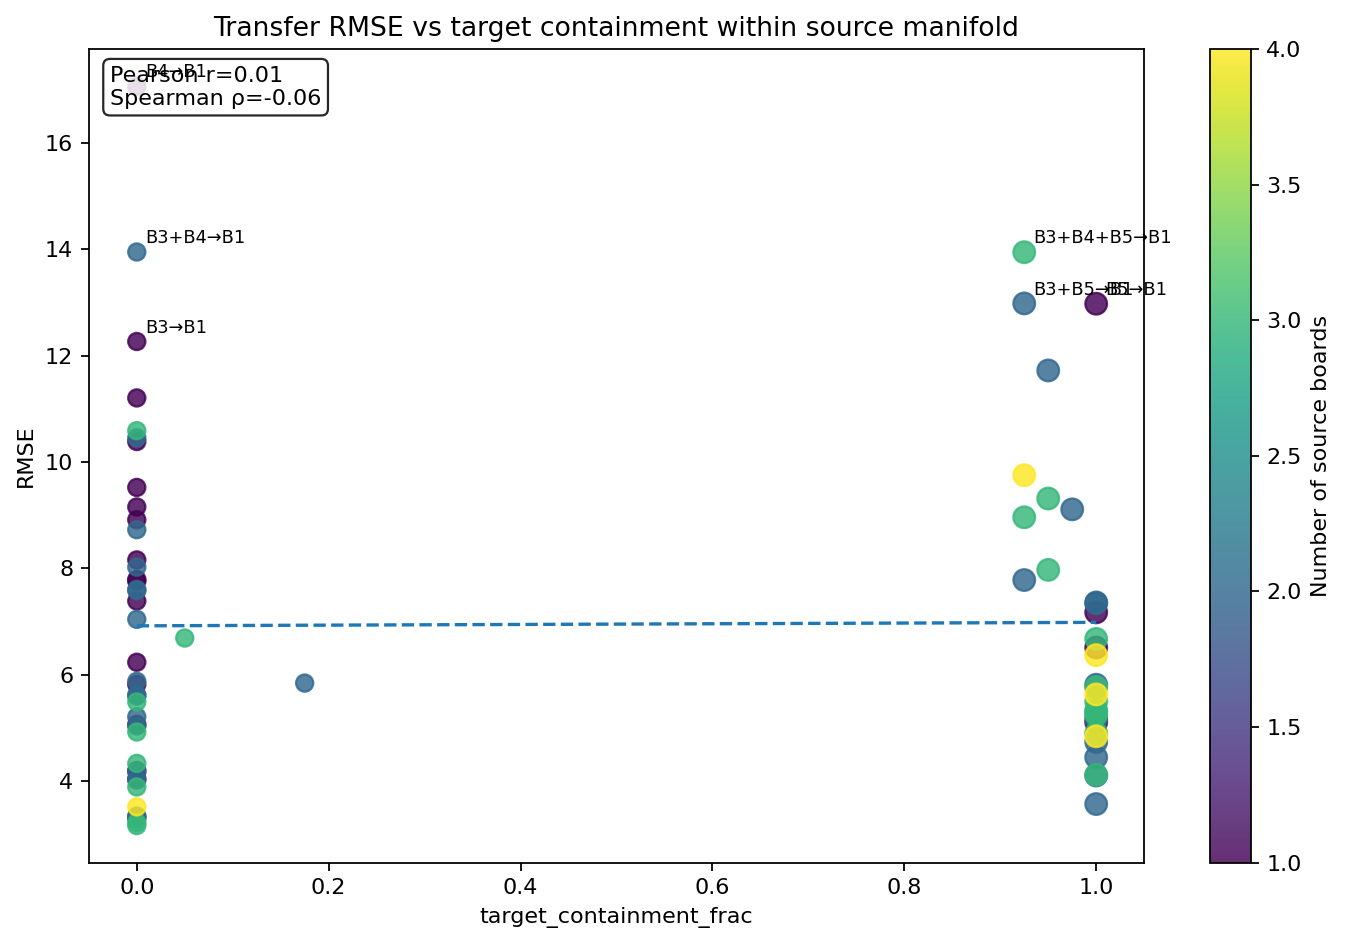

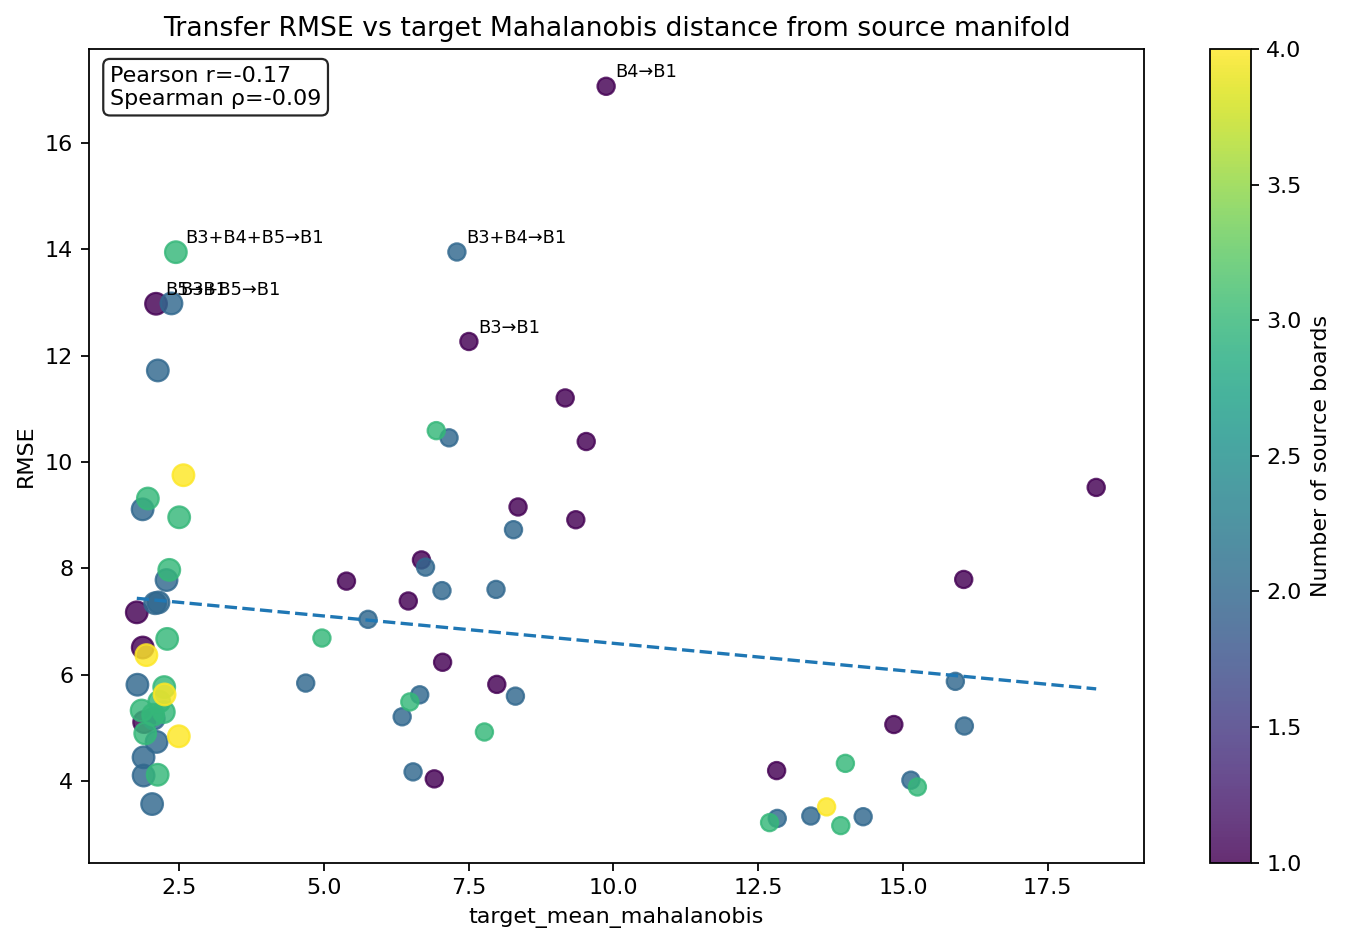

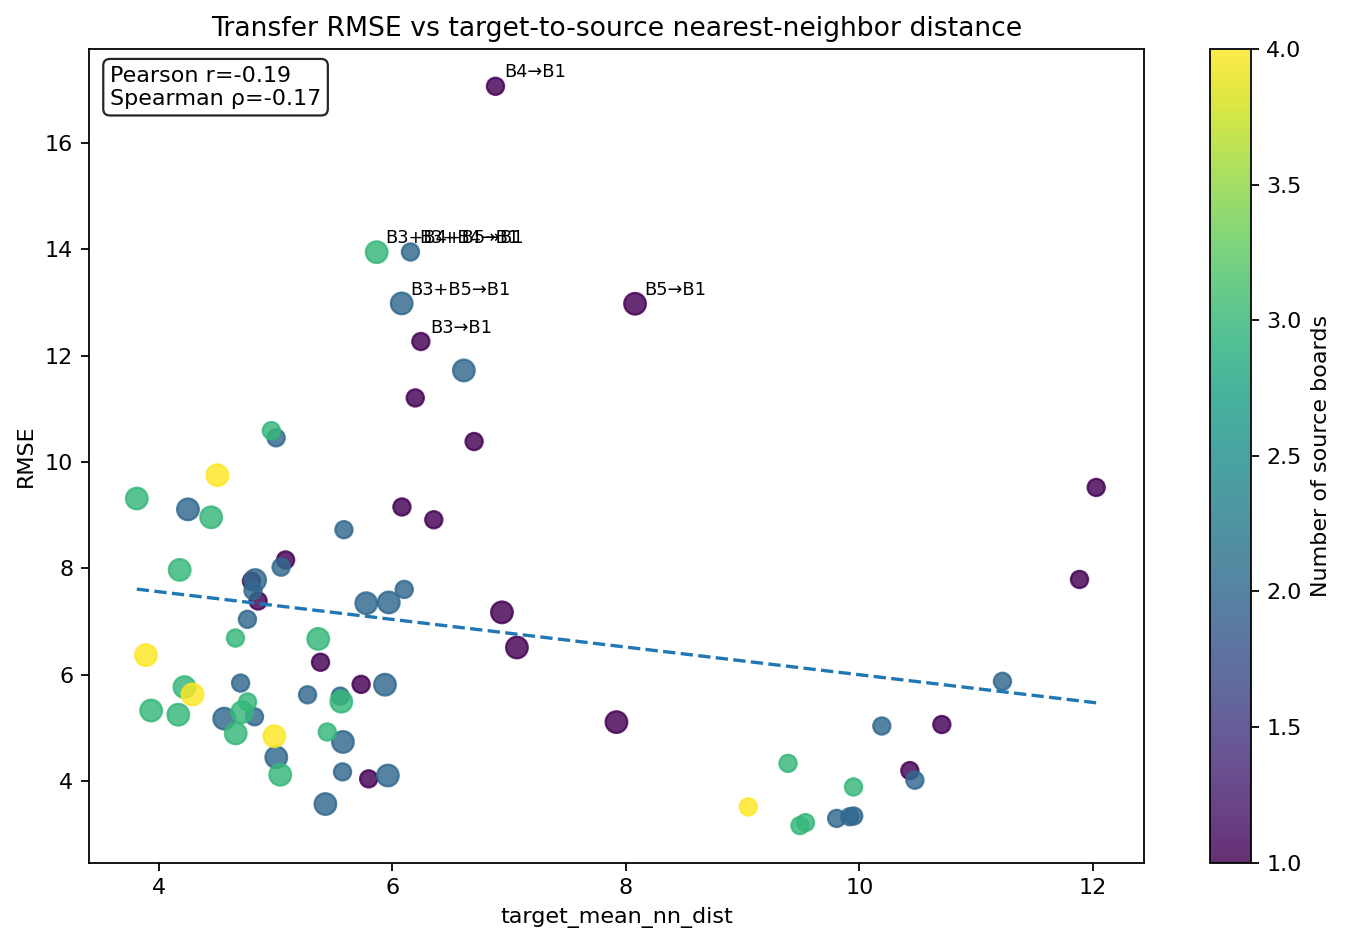

In [9]:
scatter_metric(coverage_df, "target_containment_frac", "Transfer RMSE vs target containment within source manifold", "coverage_rmse_vs_target_containment.png")
scatter_metric(coverage_df, "target_mean_mahalanobis", "Transfer RMSE vs target Mahalanobis distance from source manifold", "coverage_rmse_vs_target_mahalanobis.png")
scatter_metric(coverage_df, "target_mean_nn_dist", "Transfer RMSE vs target-to-source nearest-neighbor distance", "coverage_rmse_vs_target_nn_distance.png")

## 8. Coverage map

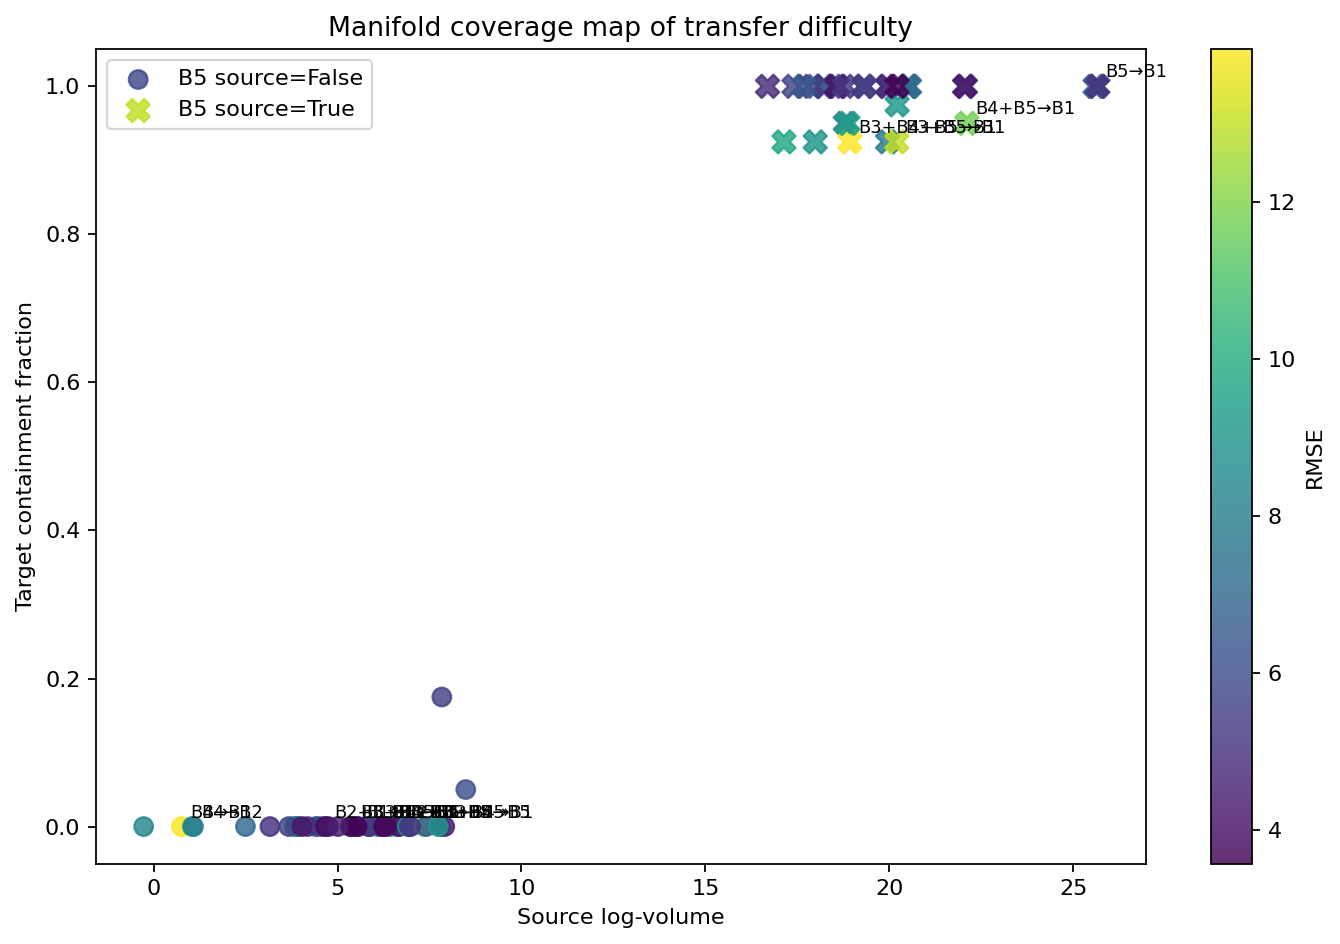

In [10]:
fig, ax = plt.subplots(figsize=(9,6), dpi=160)
for has_b5, marker, label in [(False, "o", "B5 source=False"), (True, "X", "B5 source=True")]:
    sub = coverage_df[coverage_df["b5_source"] == has_b5]
    sc = ax.scatter(sub["source_log_volume"], sub["target_containment_frac"], c=sub["rmse"],
                    s=110 if has_b5 else 70, marker=marker, alpha=0.82, label=label)
for _, r in pd.concat([coverage_df.nlargest(8,"rmse"), coverage_df.nsmallest(5,"rmse")]).drop_duplicates().iterrows():
    ax.annotate(f'{r["source_boards"]}→{r["target_board"]}', (r["source_log_volume"], r["target_containment_frac"]), fontsize=8, xytext=(4,4), textcoords="offset points")
ax.set_xlabel("Source log-volume"); ax.set_ylabel("Target containment fraction")
ax.set_title("Manifold coverage map of transfer difficulty")
ax.legend(loc="best")
cb = fig.colorbar(sc, ax=ax); cb.set_label("RMSE")
fig.tight_layout(); fig.savefig(FIG_DIR / "coverage_map_source_volume_target_containment_rmse.png", bbox_inches="tight"); plt.show()

## 9. Source-set robustness summary

In [11]:
agg = (coverage_df.groupby(["source_boards", "n_source_boards", "b5_source"], as_index=False)
       .agg(mean_rmse=("rmse","mean"), std_rmse=("rmse","std"),
            mean_source_log_volume=("source_log_volume","mean"),
            mean_source_trace=("source_trace","mean"),
            mean_target_containment=("target_containment_frac","mean"),
            mean_target_nn_dist=("target_mean_nn_dist","mean"))
       .sort_values("mean_rmse"))
agg.to_csv(RESULT_DIR / "manifold_coverage_source_set_summary.csv", index=False)
agg.head(15)

,source_boards,n_source_boards,b5_source,mean_rmse,std_rmse,mean_source_log_volume,mean_source_trace,mean_target_containment,mean_target_nn_dist
3,B1+B2+B3+B4,4,False,3.520431,NaN,6.330334,42.654103,0.000000,9.048050
2,B1+B2+B3,3,False,4.048268,1.243507,6.665710,43.877096,0.000000,7.465921
8,B1+B3,2,False,4.442826,1.291849,7.319446,45.733114,0.058333,6.691747
5,B1+B2+B4,3,False,4.693586,1.129665,5.873170,41.537441,0.000000,7.353989
11,B1+B3+B5,3,True,4.727543,0.853501,18.582194,82.327308,1.000000,4.485307
4,B1+B2+B3+B5,4,True,4.847203,NaN,16.691214,68.887851,1.000000,4.987769
9,B1+B3+B4,3,False,4.958826,2.452069,7.372514,44.886985,0.025000,7.096338
13,B1+B4+B5,3,True,5.199471,0.421512,19.315416,89.466952,1.000000,5.109305
6,B1+B2+B4+B5,4,True,5.633029,NaN,17.409520,72.271090,1.000000,4.286988
20,B2+B4,2,False,5.753425,2.055627,5.245442,37.430724,0.000000,6.779623


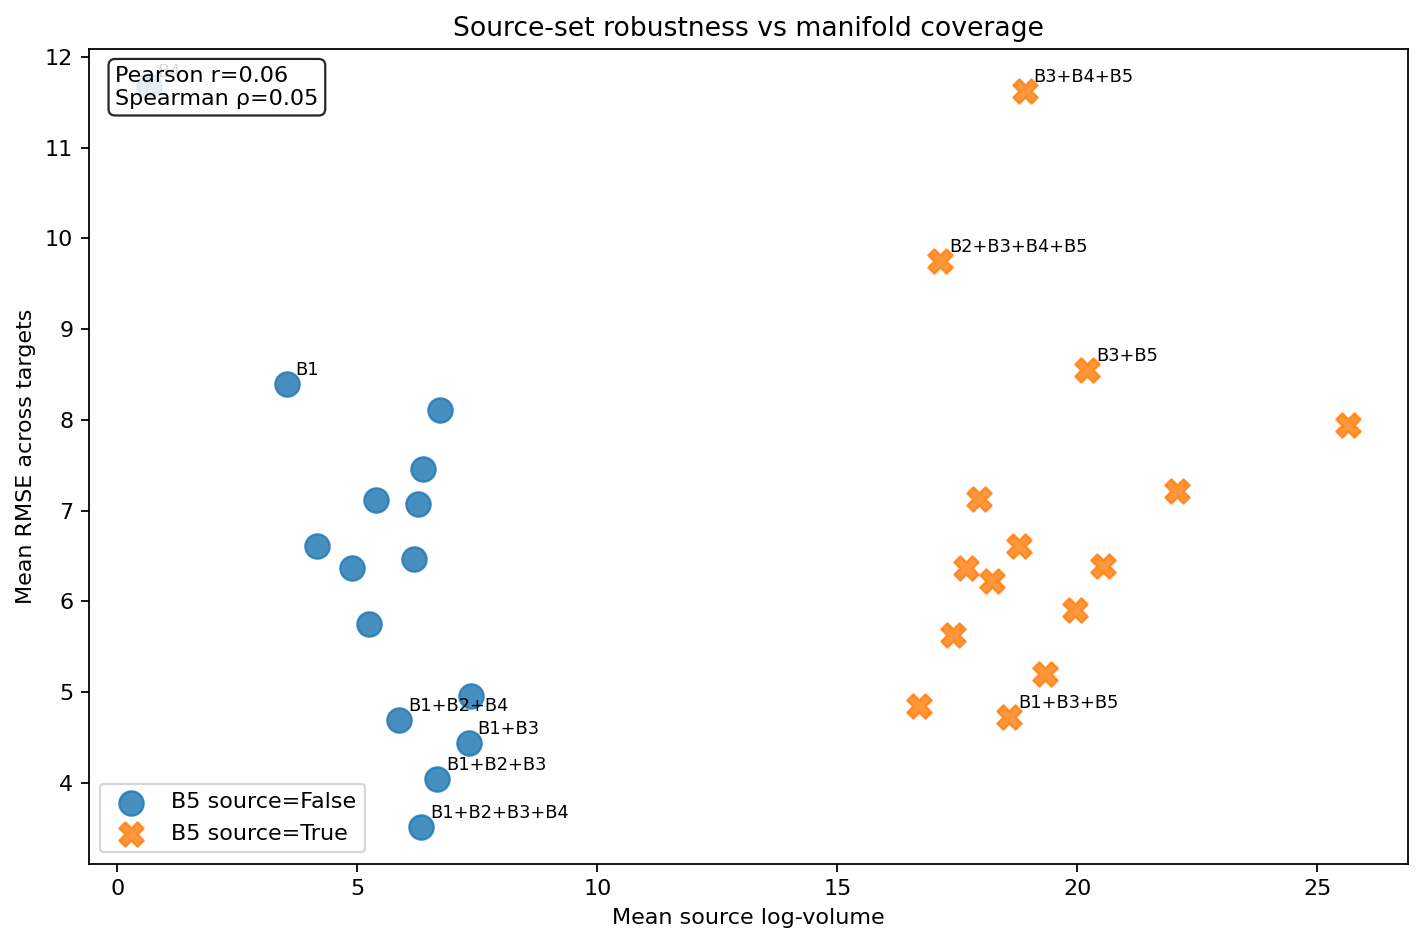

In [12]:
fig, ax = plt.subplots(figsize=(9,6), dpi=160)
for has_b5, marker, label in [(False, "o", "B5 source=False"), (True, "X", "B5 source=True")]:
    sub = agg[agg["b5_source"] == has_b5]
    ax.scatter(sub["mean_source_log_volume"], sub["mean_rmse"], s=120, marker=marker, alpha=0.82, label=label)
    for _, r in sub.iterrows():
        if r["mean_rmse"] in agg["mean_rmse"].nsmallest(5).values or r["mean_rmse"] in agg["mean_rmse"].nlargest(5).values:
            ax.annotate(r["source_boards"], (r["mean_source_log_volume"], r["mean_rmse"]), fontsize=8, xytext=(4,4), textcoords="offset points")
annotate_corr(ax, agg["mean_source_log_volume"], agg["mean_rmse"])
ax.set_xlabel("Mean source log-volume"); ax.set_ylabel("Mean RMSE across targets")
ax.set_title("Source-set robustness vs manifold coverage")
ax.legend(loc="best")
fig.tight_layout(); fig.savefig(FIG_DIR / "coverage_source_set_robustness_vs_volume.png", bbox_inches="tight"); plt.show()

## 10. Interpretation template

After running this notebook, inspect whether `target_containment_frac` is negatively associated with RMSE and whether `target_mean_mahalanobis` / `target_mean_nn_dist` are positively associated with RMSE.

A strong conclusion would be:

> Calibration transfer robustness is governed more by target containment within the source manifold than by simple source-target centroid similarity. Useful diversity expands transferable support, whereas destructive heterogeneity broadens the manifold without improving target containment.